In [ ]:
%pip install mace-torch

In [ ]:
%pip install cuequivariance cuequivariance-torch cuequivariance-ops-torch-cu12

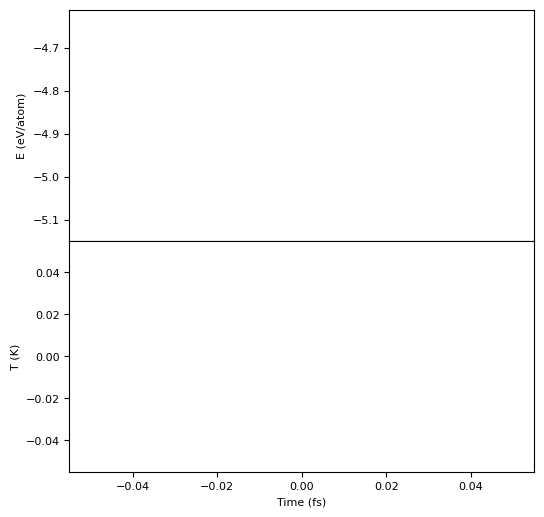

KeyboardInterrupt: 

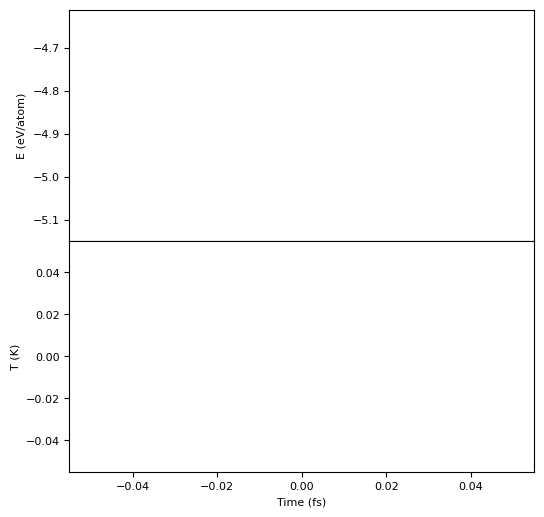

In [ ]:

from ase import Atoms
from ase.io import read, write
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution
from mace.calculators import MACECalculator
from ase import build
from ase.md import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase import units

import os
import time
import numpy as np
import pylab as pl
from IPython import display

%matplotlib inline
np.random.seed(701) #just making sure the MD failure is reproducible

init_conf : Atoms = read(os.path.join("water", "POSCAR")).repeat((3,3,3))

init_conf.calc = MACECalculator(model_paths=os.path.join("water", "water_stagetwo.model"), device="cuda", enable_cueq=False)

#initialize the temperature
Stationary(init_conf)
ZeroRotation(init_conf)

output_filename = "H2O_md.xyz"
steps : int = 300
intervals : int = 10
target_temperature : float = 300

time_fs = []
temperature = []
energies = []

dyn = Langevin(init_conf, 1.0*units.fs, temperature_K=target_temperature, friction=0.1) #drive system to desired temperature
fig, ax = pl.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

def write_frame():
    dyn.atoms.info['energy_mace'] = dyn.atoms.get_potential_energy()
    dyn.atoms.arrays['force_mace'] = dyn.atoms.calc.get_forces()
    dyn.atoms.write(output_filename, append=True)
    time_fs.append(dyn.get_time()/units.fs)
    temperature.append(dyn.atoms.get_temperature())
    energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

    ax[0].plot(np.array(time_fs), np.array(energies), color="b")
    ax[0].set_ylabel('E (eV/atom)')

    # plot the temperature of the system as subplots
    ax[1].plot(np.array(time_fs), temperature, color="r")
    ax[1].set_ylabel('T (K)')
    ax[1].set_xlabel('Time (fs)')

    display.clear_output(wait=True)
    display.display(pl.gcf())
    time.sleep(0.01)

dyn.attach(write_frame, interval=intervals)
t0 = time.time()
dyn.run(steps=steps)
t1 = time.time()
print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))